In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import transformers as tf
from transformers import DistilBertTokenizer
from transformers import get_linear_schedule_with_warmup
import torch as th
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW
import sklearn as sk
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

C:\Users\poke5\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data = pd.read_csv('data/Restaurant_Reviews.tsv', sep='\t')
print(data.isnull().sum())

Review    0
Liked     0
dtype: int64


In [3]:
# Split data 
X = data['Review']
Y = data['Liked']

X_train, X_test, Y_train, Y_test = sk.model_selection.train_test_split(X, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = sk.model_selection.train_test_split(X_test, Y_test, test_size=0.5, random_state=42)

In [4]:
# Tokenize data using DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(texts):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors='pt')

train_encodings = tokenize(X_train)
val_encodings = tokenize(X_val)
test_encodings = tokenize(X_test)

In [5]:
# Define model
model = tf.DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 194.13it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]   
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
# Train and fine-tune the model
def make_dataset(encodings, labels):
    return TensorDataset(encodings["input_ids"], encodings["attention_mask"], th.tensor(labels.values))

train_loader = DataLoader(make_dataset(train_encodings, Y_train), batch_size=16, shuffle=True)
val_loader = DataLoader(make_dataset(val_encodings, Y_val), batch_size=16)

optimizer = AdamW(model.parameters(), lr=5e-5)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=len(train_loader)*3)

device = th.device("cuda") if th.cuda.is_available() else th.device("cpu")
model.to(device)

train_losses = []
val_losses = []

for epoch in range(3):
    # Training
    model.train()
    total_train_loss = 0
    for input_ids, attention_mask, labels in train_loader:
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = model(input_ids, attention_mask=attention_mask, labels=labels).loss
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_train_loss += loss.item()

    # Validation
    model.eval()
    total_val_loss = 0
    with th.no_grad():
        for input_ids, attention_mask, labels in val_loader:
            input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
            loss = model(input_ids, attention_mask=attention_mask, labels=labels.to(device)).loss
            total_val_loss += loss.item()

    avg_train = total_train_loss / len(train_loader)
    avg_val   = total_val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    print(f"Epoch {epoch+1} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}")


Epoch 1 | Train Loss: 0.3906 | Val Loss: 0.2960
Epoch 2 | Train Loss: 0.1180 | Val Loss: 0.2352
Epoch 3 | Train Loss: 0.0327 | Val Loss: 0.2471


In [7]:
# Evaluate the Performance Metrics

model.eval()
all_preds, all_labels = [], []

with th.no_grad():
    for input_ids, attention_mask, labels in DataLoader(make_dataset(test_encodings, Y_test), batch_size=16):
        input_ids, attention_mask = input_ids.to(device), attention_mask.to(device)
        preds = model(input_ids, attention_mask=attention_mask).logits.argmax(dim=1).cpu()
        all_preds.extend(preds)
        all_labels.extend(labels)

accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall    = recall_score(all_labels, all_preds)
f1        = f1_score(all_labels, all_preds)
cm        = confusion_matrix(all_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

Accuracy:  0.9300
Precision: 0.9434
Recall:    0.9259
F1:        0.9346


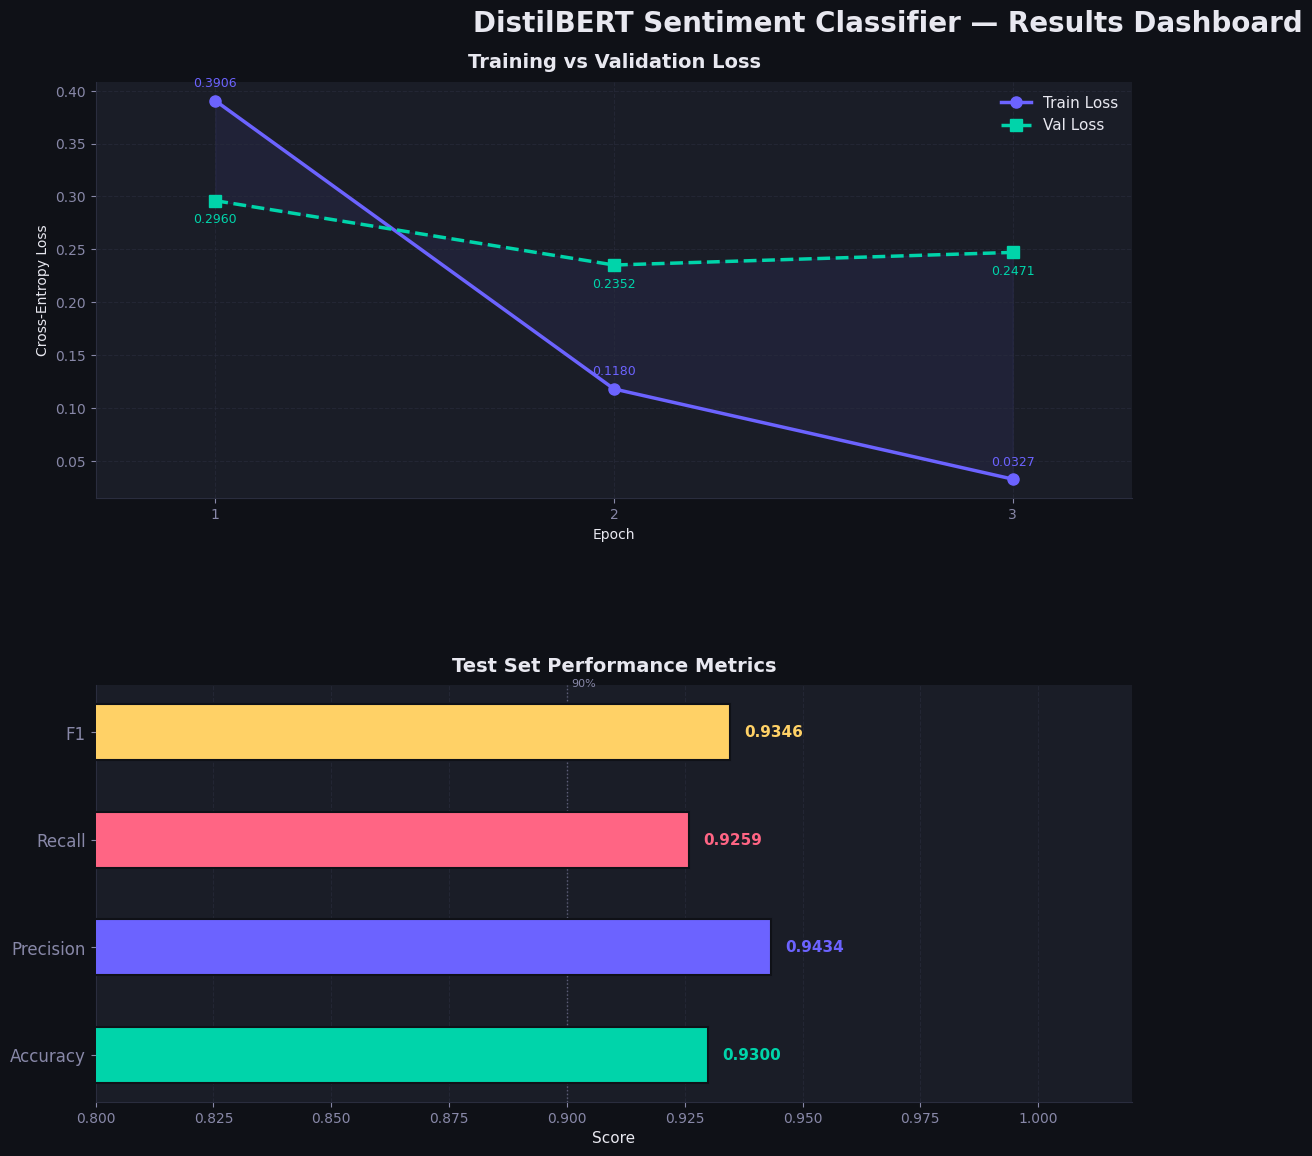

Dashboard saved to model_results_dashboard.png


In [8]:
# Visualize the results
BG      = "#0f1117"
CARD    = "#1a1d27"
ACCENT1 = "#6c63ff"
ACCENT2 = "#00d4aa"
ACCENT3 = "#ff6584"
ACCENT4 = "#ffd166"
TEXT    = "#e8e8f0"
SUBTEXT = "#8888a8"

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    CARD,
    "axes.edgecolor":    "#2a2d3e",
    "axes.labelcolor":   TEXT,
    "xtick.color":       SUBTEXT,
    "ytick.color":       SUBTEXT,
    "text.color":        TEXT,
    "grid.color":        "#2a2d3e",
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

epochs      = list(range(1, len(train_losses) + 1))
metric_names = ["Accuracy", "Precision", "Recall", "F1"]
metric_vals  = [accuracy, precision, recall, f1]
metric_cols  = [ACCENT2, ACCENT1, ACCENT3, ACCENT4]
class_counts = [sum(l.item() == 0 for l in all_labels), sum(l.item() == 1 for l in all_labels)]

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle("DistilBERT Sentiment Classifier — Results Dashboard",
             fontsize=20, fontweight="bold", color=TEXT, y=0.98)
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.38,
                      left=0.06, right=0.97, top=0.92, bottom=0.07)

# Loss Curves
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, train_losses, "o-", color=ACCENT1, lw=2.5, ms=8, label="Train Loss", zorder=3)
ax1.plot(epochs, val_losses,   "s--", color=ACCENT2, lw=2.5, ms=8, label="Val Loss",   zorder=3)
ax1.fill_between(epochs, train_losses, val_losses, alpha=0.08, color=ACCENT1)
for e, tl, vl in zip(epochs, train_losses, val_losses):
    ax1.annotate(f"{tl:.4f}", (e, tl), textcoords="offset points", xytext=(0, 10),  ha="center", fontsize=9, color=ACCENT1)
    ax1.annotate(f"{vl:.4f}", (e, vl), textcoords="offset points", xytext=(0, -16), ha="center", fontsize=9, color=ACCENT2)
ax1.set_title("Training vs Validation Loss", fontsize=14, fontweight="bold", color=TEXT, pad=10)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_xticks(epochs); ax1.set_xlim(0.7, len(epochs) + 0.3)
ax1.legend(framealpha=0, fontsize=11); ax1.grid(True)

#  Metrics bar chart
ax3 = fig.add_subplot(gs[1, :2])
y_pos = np.arange(len(metric_names))
bars = ax3.barh(y_pos, metric_vals, height=0.52, color=metric_cols, zorder=3, edgecolor=BG, linewidth=1.5)
ax3.set_yticks(y_pos); ax3.set_yticklabels(metric_names, fontsize=12)
ax3.set_xlim(0.80, 1.02); ax3.set_xlabel("Score", fontsize=11)
ax3.set_title("Test Set Performance Metrics", fontsize=14, fontweight="bold", color=TEXT, pad=10)
for bar, score, col in zip(bars, metric_vals, metric_cols):
    ax3.text(score + 0.003, bar.get_y() + bar.get_height() / 2,
             f"{score:.4f}", va="center", fontsize=11, fontweight="bold", color=col)
ax3.axvline(0.90, color=SUBTEXT, lw=1, ls=":", alpha=0.6)
ax3.text(0.901, 3.42, "90%", color=SUBTEXT, fontsize=8)
ax3.grid(True, axis="x")

plt.savefig("model_results_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()
print("Dashboard saved to model_results_dashboard.png")